In [ ]:
!pip install python-dotenv huggingface_hub datasets matplotlib transformers scikit-learn numpy gensim

In [1]:
# imports

import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
## # environment
load_dotenv(override=True)

# Get the HF token from environment variables
hf_token = os.getenv('HF_TOKEN')

# Log in to Hugging Face
login(hf_token, add_to_git_credential=True)

In [3]:
# Load in our dataset
rawdata = load_dataset("cogsci13/Amazon-Reviews-2023-Books-Meta", split="full", trust_remote_code=True)
#print(dataset[0])

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'cogsci13/Amazon-Reviews-2023-Books-Meta' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/28 [00:00<?, ?it/s]

## Data Exploration

In [4]:
len(rawdata)

4448181

In [5]:
print(rawdata[0])

{'main_category': 'Books', 'title': 'Chaucer', 'average_rating': 4.5, 'rating_number': 29, 'features': [], 'description': [], 'price': '8.23', 'images': {'hi_res': [None], 'large': ['https://m.media-amazon.com/images/I/41X61VPJYKL._SX334_BO1,204,203,200_.jpg'], 'thumb': [None], 'variant': ['MAIN']}, 'videos': {'title': [], 'url': [], 'user_id': []}, 'store': 'Peter Ackroyd (Author)', 'categories': ['Books', 'Literature & Fiction', 'History & Criticism'], 'details': '{"Publisher": "Chatto & Windus; First Edition (January 1, 2004)", "Language": "English", "Hardcover": "196 pages", "ISBN 10": "0701169850", "ISBN 13": "978-0701169855", "Item Weight": "10.1 ounces", "Dimensions": "5.39 x 0.71 x 7.48 inches"}', 'parent_asin': '0701169850', 'bought_together': None, 'subtitle': 'Hardcover – Import, January 1, 2004', 'author': "{'avatar': 'https://m.media-amazon.com/images/I/21Je2zja9pL._SY600_.jpg', 'name': 'Peter Ackroyd', 'about': ['Peter Ackroyd, (born 5 October 1949) is an English biograph

In [6]:
# Investigate a particular datapoint
datapoint = rawdata[1]
datapoint

{'main_category': 'Books',
 'title': 'Notes from a Kidwatcher',
 'average_rating': 5.0,
 'rating_number': 1,
 'features': ["Contains 23 selected articles by this influential writer, researcher, educator, and speaker. They're grouped around six major themes inherent in teacher education: culture and community; miscue analysis, reading strategies and comprehension; print awareness and the roots of literacy; the writing process; kidwatching; and whole language theory. No index. Annotation c. by Book News, Inc., Portland, Or."],
 'description': ['About the Author',
  "SANDRA WILDE, Ph.D., is widely recognized for her expertise in developmental spelling and her advocacy of holistic approaches to spelling and phonics. She is Professor of Curriculum and Instruction at Portland State University in Oregon. She is best known for her work in invented spelling, phonics and miscue analysis. She specializes in showing teachers how kids' invented spellings and miscues can help us work with them in mo

In [7]:
# Investigate
datapoint = rawdata[5]
print(datapoint["title"])
print(datapoint["description"])
print(datapoint["features"])
print(datapoint["details"])
print(datapoint["price"])

Writings from a Black Woman Living in the Land of the "Free": Strength, Power, Resilience
[]
["Take a step into the modern perspective of a young black woman living in America. Tori Ruff explores the injustices and pain endured by the African American community for centuries. Through a series of writings, she speaks on topics including police brutality, racism, and discrimination. 'Writings from a Black Woman Living in the Land of the Free' takes readers on a journey of empathy and a sense of empowerment."]
{"Publisher": "Independently published (December 30, 2021)", "Language": "English", "Paperback": "24 pages", "ISBN 13": "979-8528537702", "Item Weight": "3.2 ounces", "Dimensions": "7 x 0.06 x 9 inches"}
4.05


In [8]:
# How many have prices?

prices = 0
for datapoint in rawdata:
    try:
        price = float(datapoint["price"])
        if price > 0:
            prices += 1
    except ValueError as e:
        pass

print(f"There are {prices:,} with prices which is {prices/len(rawdata)*100:,.1f}%")

There are 3,286,798 with prices which is 73.9%


In [9]:
#Filter only records with prices

filtered = (dp for dp in rawdata if "price" in dp and isinstance(dp["price"], str) and dp["price"].replace('.', '', 1).isdigit() and float(dp["price"]) > 0)

In [10]:
# Convert a sample of filtered data to in-memory dataset
sampled_data = []
for i, dp in enumerate(filtered):
    if i >= 100000:  # pick a reasonable sample size, e.g. 10k
        break
    sampled_data.append(dp)

dataset = Dataset.from_list(sampled_data)
print(f"Loaded {len(dataset):,} examples with prices.")

Loaded 100,000 examples with prices.


In [12]:
prices = []
lengths = []

for datapoint in dataset:
    try:
        price = float(datapoint["price"])
        if price > 0:
            prices.append(price)
            contents = (
                datapoint["title"] +
                str(datapoint.get("description", "")) +
                str(datapoint.get("features", "")) +
                str(datapoint.get("details", ""))
            )
            lengths.append(len(contents))
    except ValueError:
        pass

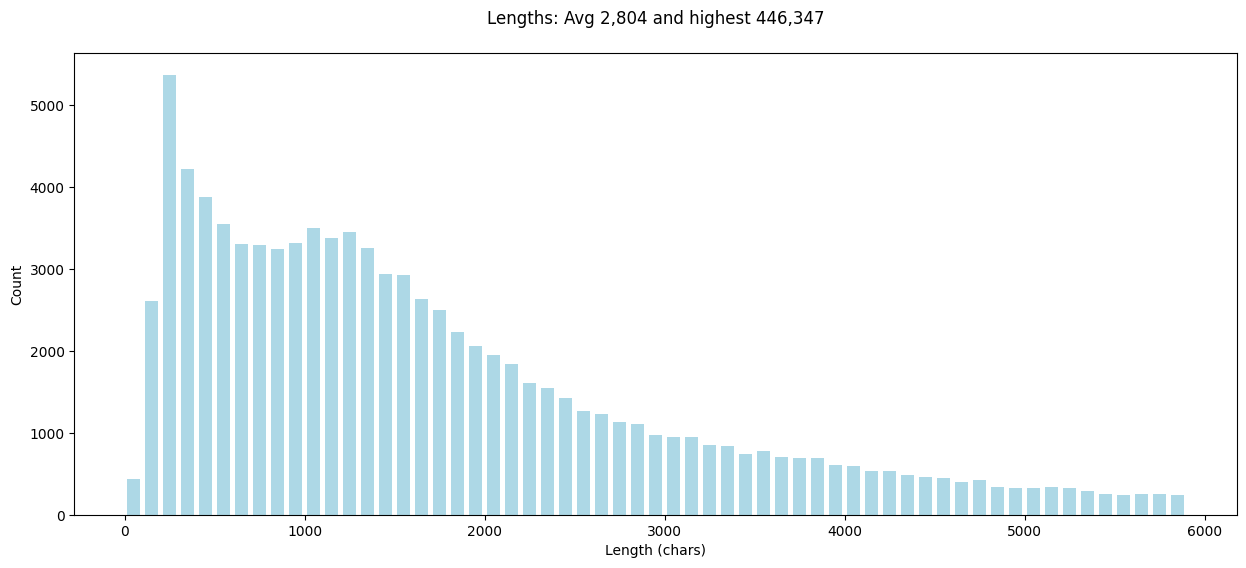

In [13]:
# Plot lengths
plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

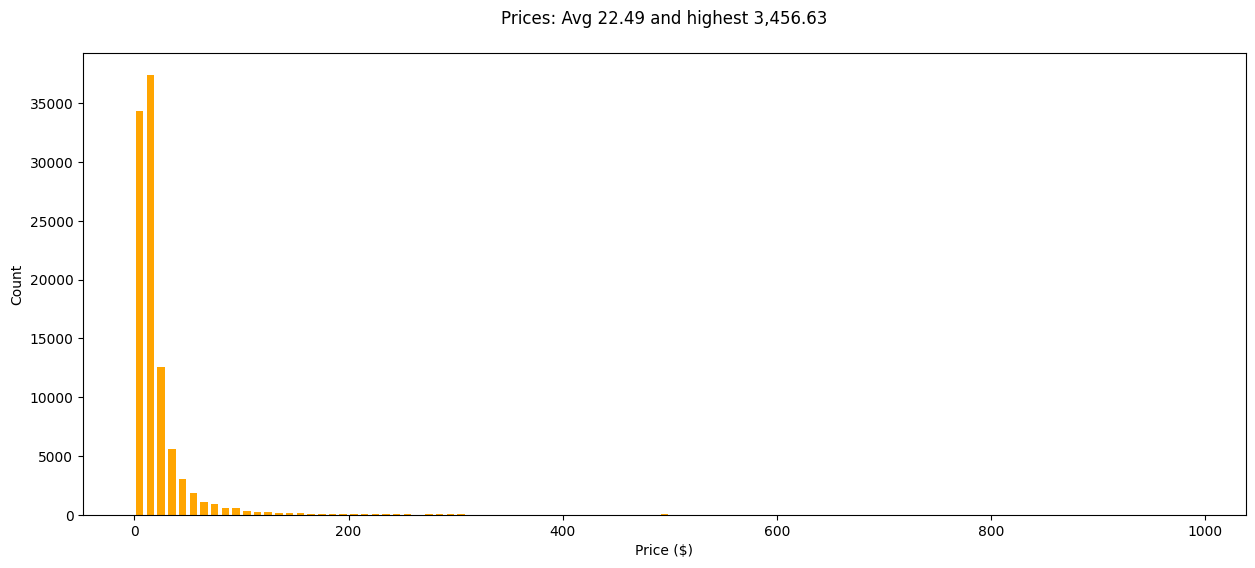

In [14]:
# Plot prices
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

In [15]:
# So what is this book??

for datapoint in dataset:
    try:
        price = float(datapoint["price"])
        if price > 3400:
            print(datapoint['title'])
    except ValueError as e:
        pass

More harvest festival dramas of Tibet,


## Data Transform (Data clear - Tokenization - Data Quality - Prompt standardization)

In [16]:
from transformers import AutoTokenizer
import re ## regrex: xử lý văn bản trong lib python

BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B"
MIN_TOKENS = 150  # Any less than this, and we don't have enough useful content 1 token = 4 chars
MAX_TOKENS = 160  # Truncate after this many tokens
MIN_CHARS = 300
CEILING_CHARS = MAX_TOKENS * 7

In [17]:
def clean_text(text: str) -> str:
    # Remove unnecessary characters
    text = re.sub(r'[:\[\]"{}【】\s]+', ' ', text).strip()
    text = text.replace(" ,", ",").replace(",,,",",").replace(",,",",")
    words = text.split(' ')
    # Remove likely product codes
    select = [word for word in words if len(word) < 7 or not any(char.isdigit() for char in word)]
    return " ".join(select)

In [18]:
text = 'Writings from a Black Woman Living in the Land of the "Free": Strength, Power, Resilience'
cleaned = clean_text(text)
print(cleaned)

Writings from a Black Woman Living in the Land of the Free Strength, Power, Resilience


In [ ]:
# BookItems.py

In [21]:
from BookItems import BookItem

OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Meta-Llama-3.1-8B.
403 Client Error. (Request ID: Root=1-68b79228-57acc67016e8bdce2a78efd3;97cceaec-54fe-438f-9166-bda30987bb20)

Cannot access gated repo for url https://huggingface.co/meta-llama/Meta-Llama-3.1-8B/resolve/main/config.json.
Access to model meta-llama/Llama-3.1-8B is restricted and you are not in the authorized list. Visit https://huggingface.co/meta-llama/Llama-3.1-8B to ask for access.